# Methods

My process for this project can be broken down into two phases: debugging to get a successful model and then a lot of excperimentation and fine tuning. In order to get the model to function correctly for the entire test set as well as output in the correct formatting, I ended up modifying the predict function significantly as well as created a workflow where the predictions are saved to a .json file and then further converted into a .csv for the correct submission format. This workflow helped make sure the model's prediction function worked correctly. Then, for experimenting, I tried several methods to expand and fine tune the model. Extensive documentation regarding my experimentation process can be found at the bottom of this notebook, which includes all of the information regarding my experimentation process and results.  

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/README.dataset.txt
/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/README.roboflow.txt
/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/valid/Ccr-2-stem-19_png.rf.2a394b91faf9bd5c22f2de21c83e1fe4.jpg
/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/valid/Rca-1-stem-15_png.rf.64732016056cb78e7c5a6c814cdb7b18.jpg
/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/valid/Rca-2-stem-11_png.rf.4f18509868de74ba2f96c4befa7e0d84.jpg
/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/valid/Ccr-1-stem-4_png.rf.d6d267299d7cdd4316db3a254ba493d0.jpg
/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/valid/Ccr-3-stem-2_png.rf.ff1590e493333217eca7def67e61ce68.jpg
/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/valid/Co-1-stem-6_png.rf.e2

# Load all dependencies eg. PyTorch



In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import json
import os
import pandas as pd

In [3]:
from pycocotools.coco import COCO

# Load COCO annotations
coco = COCO('/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/train/_annotations.coco.json')

# Get image details
image_id = 0
image_info = coco.loadImgs(image_id)[0]
image_path = image_info['file_name']

# Get annotations for the image
ann_ids = coco.getAnnIds(imgIds=image_id)
annotations = coco.loadAnns(ann_ids)

# Print image path and bounding boxes
print("Image Path:", image_path)
print("Bounding Boxes:", [ann['bbox'] for ann in annotations])

#You can use this information to load the data yourself in a systematic way!

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Image Path: Rca-2-stem-2_png.rf.0284dd4e9ba491e72200c347ed97c3b2.jpg
Bounding Boxes: [[206, 308, 61.5, 99], [298, 125, 95, 153.5], [360, 79, 89.5, 109.5], [318, 395, 71, 96.5], [194, 507, 66.5, 76.5], [178, 549, 47, 68.5], [73, 86, 83, 112], [121, 134, 88, 103], [199, 2, 92.5, 45], [546, 188, 87, 120.5], [582, 92, 57.5, 133], [480, 0, 86.5, 36.5], [305, 569, 58.5, 70.5], [362, 598, 36, 42], [0, 192, 64, 103], [0, 74, 16, 68.5], [1, 359, 27, 70], [341, 274, 47, 44], [389, 283, 42.5, 42.5], [371, 356, 57.5, 61.5], [328, 351, 40, 35.5]]


# Define PyTorch Dataset and Dataloading

In [4]:
#folder and annotations are provided from me
image_dir = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/train/'
annotations_file = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/train/_annotations.coco.json'


class CustomCocoDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transforms=None):
        self.image_dir = image_dir
        self.transforms = transforms

        with open(annotation_file, 'r') as f:
            self.coco_data = json.load(f)

        self.images = self.coco_data['images']
        self.annotations = self.coco_data['annotations']
        self.categories = self.coco_data['categories']

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_info = self.images[idx]
        img_path = os.path.join(self.image_dir, image_info['file_name'])
        img = Image.open(img_path).convert("RGB")

        ann_ids = [ann for ann in self.annotations if ann['image_id'] == image_info['id']]

        boxes = []
        labels = []

        for ann in ann_ids:
            bbox = ann['bbox']
            # Convert bbox format from [x,y,width,height] to [x_min, y_min, x_max, y_max]
            xmin = bbox[0]
            ymin = bbox[1]
            xmax = bbox[0] + bbox[2]
            ymax = bbox[1] + bbox[3]
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(ann['category_id'] + 1)  # Start labels from 1 (background is 0 therefore the vessel should be 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        if self.transforms:
            img = self.transforms(img)

        return img, target


transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = CustomCocoDataset(image_dir, annotations_file, transforms=transform)
#EXPERIMENT: testing batch sizes to see its effect on the model's accuracy
data_loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

print(dataset.__getitem__(0))

(tensor([[[0.7255, 0.7373, 0.7608,  ..., 0.7804, 0.7961, 0.8039],
         [0.7216, 0.7333, 0.7529,  ..., 0.7804, 0.7922, 0.7961],
         [0.7098, 0.7255, 0.7451,  ..., 0.7961, 0.8000, 0.7961],
         ...,
         [0.9176, 0.9216, 0.9333,  ..., 0.7373, 0.7137, 0.6902],
         [0.9020, 0.9176, 0.9412,  ..., 0.6980, 0.6784, 0.6588],
         [0.8941, 0.9176, 0.9490,  ..., 0.6784, 0.6745, 0.6667]],

        [[0.8471, 0.8588, 0.8667,  ..., 0.7922, 0.8157, 0.8235],
         [0.8392, 0.8549, 0.8627,  ..., 0.7922, 0.8118, 0.8157],
         [0.8353, 0.8431, 0.8549,  ..., 0.8078, 0.8157, 0.8235],
         ...,
         [0.8471, 0.8510, 0.8627,  ..., 0.7059, 0.6706, 0.6471],
         [0.8314, 0.8471, 0.8706,  ..., 0.6706, 0.6431, 0.6235],
         [0.8235, 0.8471, 0.8784,  ..., 0.6510, 0.6392, 0.6314]],

        [[0.7882, 0.8000, 0.8078,  ..., 0.4824, 0.4941, 0.5020],
         [0.7922, 0.7961, 0.8078,  ..., 0.4824, 0.4980, 0.5020],
         [0.7922, 0.7961, 0.8000,  ..., 0.5059, 0.5137, 0

# Load Pre-trained Fasterrcnn_ResNet50

In [5]:
# Load model
num_classes = len(dataset.categories) + 1
model = fasterrcnn_resnet50_fpn(pretrained=True)

# Properly redefine the box predictor
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes) #the pre-trained fasterrcnn is on coco (91 classes) we need to adapt to 2 classes

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)
model.to(device)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 165MB/s]


cuda


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# Choosing optimization parameters
## Optimizer and Scheduler

In [6]:
params = [p for p in model.parameters() if p.requires_grad]  #in the pre-trained model allow certain parameters to be optimized
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

#weight decay helps deal with overfitting, regularization prevents large weights I beieve

# Learning rate scheduler
#every 3 steps reduce LR by magnitude of 10
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# Simple Training Loop

In [7]:
#EXPERIMENT: Changing the number of epochs to see if performance improves
num_epochs = 17
loss_per_epoch = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, targets in data_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        running_loss += losses.item()

        optimizer.zero_grad()
          
        losses.backward()
        optimizer.step()
    # Step the learning rate scheduler
    lr_scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(data_loader)}")
    #adding loss per epoch for visualization below
    loss_per_epoch.append(running_loss / len(data_loader))


Epoch 1/17, Loss: 0.8196936463805992
Epoch 2/17, Loss: 0.6222627832436226
Epoch 3/17, Loss: 0.5376327606573911
Epoch 4/17, Loss: 0.44943041805650147
Epoch 5/17, Loss: 0.4174164267073215
Epoch 6/17, Loss: 0.4042422437751797
Epoch 7/17, Loss: 0.38999007946588626
Epoch 8/17, Loss: 0.3873339335263615
Epoch 9/17, Loss: 0.3828832734848412
Epoch 10/17, Loss: 0.38368791000733915
Epoch 11/17, Loss: 0.38260155580413174
Epoch 12/17, Loss: 0.38152740974451455
Epoch 13/17, Loss: 0.38072277154301254
Epoch 14/17, Loss: 0.3842508947135697
Epoch 15/17, Loss: 0.3833662277795899
Epoch 16/17, Loss: 0.3824589598241826
Epoch 17/17, Loss: 0.3826725963555591


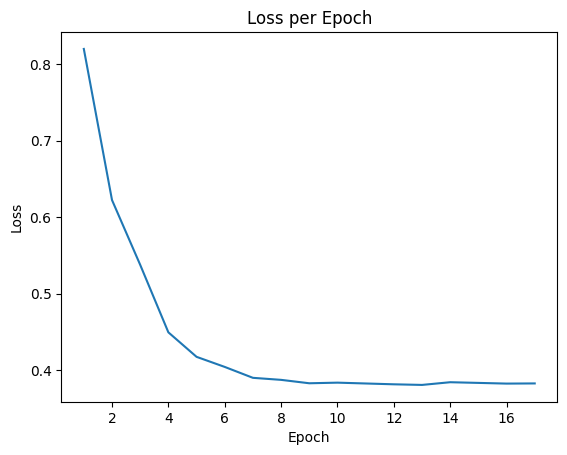

In [8]:
#epoch loss visualization to check for effectiveness

plt.plot(range(1, num_epochs + 1), loss_per_epoch)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.show()

# Save Fine-Tuned Model

In [9]:
# Save model
torch.save(model.state_dict(), 'fasterrcnn_resnet50_fpn_custom.pth')

# Load model
model.load_state_dict(torch.load('fasterrcnn_resnet50_fpn_custom.pth'))
model.eval()

<ipython-input-9-ba64a44ec606>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('fasterrcnn_resnet50_fpn_custom.pth'))


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

# Predict on test images + save to .json file

In [10]:
#The predictor 
def predict(image_path, model, device, confidence_threshold=0.57):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([transforms.ToTensor()])
    image = transform(image).to(device)
    model.eval()
    with torch.no_grad():
        prediction = model([image])
        
    prediction_list = []
#______________________________________________________________________________________________________________________________
#EDITING: Trying to fix how the boudning boxes and Category ID's are saved
#EXPERIMENT: Adding Confidence threshold, tweaking it, and seeing what happens
    #Get predictions from the first image in the batch
    boxes = prediction[0]['boxes']
    labels = prediction[0]['labels']
    scores = prediction[0]['scores']
    
    for box, label, score in zip(boxes, labels, scores):
        if score >= confidence_threshold:
            x1, y1, x2, y2 = box.cpu().numpy()
            bbox = [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]  #Convert from [x1, y1, x2, y2] to [x, y, width, height]
            prediction_list.append({
                'bbox': bbox,
                #forcing the categoryID back to 1 because it kept coming up as 2
                'category_id': 1
            }) 
        
    return prediction_list
#______________________________________________________________________________________________________________________________
#predict on all of the test set images IN THE RIGHT ORDER
#Putting the files in the correct order
test_images_path = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/test/'
files_in_order = ['Co-1-root-5_png.rf.04fe6681c9775758c76bbfbbe965cb9c.jpg',
                  'Ccr-3-stem-4_png.rf.ad5071bea4640496e9cce5a8cac58b63.jpg', 
                  'Ccr-1-stem-5_png.rf.98a392c1175ddd538e98ab612961a042.jpg', 
                  'Co-3-stem-16_png.rf.aeb57797138101605ff72c1153a7a57d.jpg', 
                  'Rca-2-root-2_png.rf.eb8aefc7736938e52a1633bdad5828ad.jpg', 
                  'Rca-3-root-4_png.rf.74dded54411abd9662fb24801b74fb1f.jpg', 
                  'Ccr-1-root-5_png.rf.3891ea52467abfd4a9601d9d141bc71c.jpg', 
                  'Co-2-stem-1_png.rf.6797c19c7c90cf2adafc15f1edd291f7.jpg', 
                  'Rca-2-root-11_png.rf.d4a7247a11be8165a6a1fa8a2fbb2c21.jpg', 
                  'Rca-1-stem-5_png.rf.96f6b2e78b93061fbfef6fa8641ba657.jpg']
predictions = []

for img in files_in_order:
    image_path = f'{test_images_path}/{img}'
    prediction = predict(image_path, model, device)
    predictions.append((img, prediction))

for img, prediction in predictions:
    print(f"Predictions for {img}: {prediction}")

with open('test_predictions.json', 'w') as json_file:
    json.dump(predictions, json_file, indent=4)
    print('Predictions have now been saved to the filename test_predictions! :)')

Predictions for Co-1-root-5_png.rf.04fe6681c9775758c76bbfbbe965cb9c.jpg: [{'bbox': [441.1673889160156, 351.7779235839844, 172.80520629882812, 195.86819458007812], 'category_id': 1}, {'bbox': [311.48516845703125, 358.6455993652344, 95.34219360351562, 119.36563110351562], 'category_id': 1}, {'bbox': [246.3762664794922, 237.7039794921875, 71.31886291503906, 85.71762084960938], 'category_id': 1}, {'bbox': [275.5163269042969, 136.08604431152344, 57.579742431640625, 66.96138000488281], 'category_id': 1}, {'bbox': [349.2646179199219, 165.39170837402344, 80.00091552734375, 101.94920349121094], 'category_id': 1}, {'bbox': [526.2899780273438, 11.347424507141113, 54.95849609375, 68.33952331542969], 'category_id': 1}, {'bbox': [500.82330322265625, 299.8328857421875, 69.2369384765625, 58.2705078125], 'category_id': 1}]
Predictions for Ccr-3-stem-4_png.rf.ad5071bea4640496e9cce5a8cac58b63.jpg: [{'bbox': [277.8022766113281, 0.0, 93.74029541015625, 76.59962463378906], 'category_id': 1}, {'bbox': [0.0, 

In [11]:
#checking to see if the file is saved and where
for root, dirs, files in os.walk("/"):
    if "test_predictions.json" in files:
        print(os.path.join(root, "test_predictions.json"))


/kaggle/working/test_predictions.json


# Output to .csv file

In [12]:
#Reloading the TEST data so that we have the original data not the tensors
test_images_dir = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/test/'
test_predictions_path = '/kaggle/working/test_predictions.json'
with open(test_predictions_path, 'r') as f:
    test_predictions = json.load(f)

#filter out the filenames of the images from the predictions file
image_filenames_in_predictions = [pred[0] for pred in test_predictions]
#isolating the bounding boxes for the output column
#I am changing this based on how I just changed the .json file format
bounding_box_list = [[obj['bbox'] for obj in entry[1]] for entry in test_predictions]

#Assigning the correct data to the right column spot and name
#CHANGE THIS
image_ids = list(range(len(image_filenames_in_predictions)))
#I am changing this based on how I just changed the .json file format
categoryIDs_list = [[obj['category_id'] for obj in entry[1]] for entry in test_predictions]
usage = ['Public'] * len(image_filenames_in_predictions)

#the dataframe output
output = pd.DataFrame({
    'ID': image_ids,
    'FileName': image_filenames_in_predictions,
    'BoundingBoxes': bounding_box_list, 
    'CategoryIDs': categoryIDs_list,
    'Usage': usage
})
output.to_csv('submission.csv', index=False)
print('YAY!!! The model and output system worked! :)')

YAY!!! The model and output system worked! :)


In [13]:
#test to make sure it's just the test set in the submission file 
print(len(image_ids))
print(len(bounding_box_list))
print(len(categoryIDs_list))
print(len(usage))

print("Test Images Directory:", test_images_dir)
print("Test Image Filenames:", image_filenames_in_predictions[:10])

10
10
10
10
Test Images Directory: /kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/test/
Test Image Filenames: ['Co-1-root-5_png.rf.04fe6681c9775758c76bbfbbe965cb9c.jpg', 'Ccr-3-stem-4_png.rf.ad5071bea4640496e9cce5a8cac58b63.jpg', 'Ccr-1-stem-5_png.rf.98a392c1175ddd538e98ab612961a042.jpg', 'Co-3-stem-16_png.rf.aeb57797138101605ff72c1153a7a57d.jpg', 'Rca-2-root-2_png.rf.eb8aefc7736938e52a1633bdad5828ad.jpg', 'Rca-3-root-4_png.rf.74dded54411abd9662fb24801b74fb1f.jpg', 'Ccr-1-root-5_png.rf.3891ea52467abfd4a9601d9d141bc71c.jpg', 'Co-2-stem-1_png.rf.6797c19c7c90cf2adafc15f1edd291f7.jpg', 'Rca-2-root-11_png.rf.d4a7247a11be8165a6a1fa8a2fbb2c21.jpg', 'Rca-1-stem-5_png.rf.96f6b2e78b93061fbfef6fa8641ba657.jpg']


# Prediction Visualization for Test Set

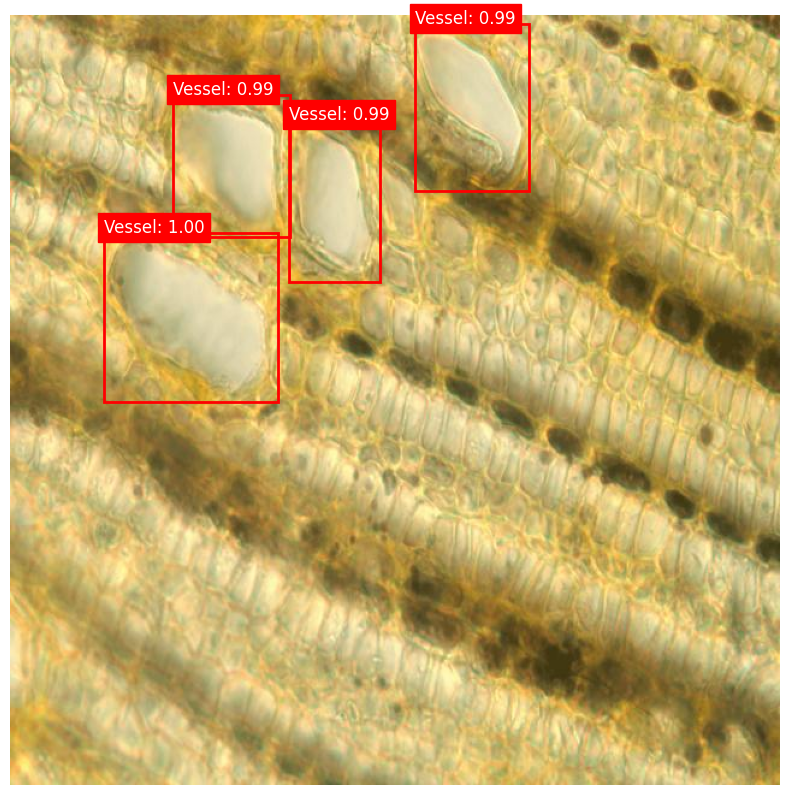

In [14]:
#This is a visualizationn of images from the test set
#This version predicts on its own and does not use the .json file data

def train_predict(image_path, model, device):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([transforms.ToTensor()])
    image = transform(image).to(device)
    model.eval()
    with torch.no_grad():
        train_prediction = model([image])

    return train_prediction

test_image_path = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/test/Co-2-stem-1_png.rf.6797c19c7c90cf2adafc15f1edd291f7.jpg'
predictions = train_predict(test_image_path, model, device)

def display_prediction(test_image_path, predictions, threshold=0.57):
    image = Image.open(test_image_path).convert("RGB")
    plt.figure(figsize=(10,10))
    plt.imshow(image)

    test_prediction = predictions[0]
    boxes = test_prediction['boxes'].cpu().numpy()
    scores = test_prediction['scores'].cpu().numpy()
    labels = test_prediction['labels'].cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        if score > threshold:
            xmin, ymin, xmax, ymax = box
            plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                                  linewidth=2, edgecolor='red', facecolor='none'))
            plt.text(xmin, ymin, f"{dataset.categories[label-1]['name']}: {score:.2f}",
                         color='white', fontsize=12, backgroundcolor='red')
    
    plt.axis('off')
    plt.show()
      
# Display the predictions
display_prediction(test_image_path, predictions)


# Prediction Visualization for 1 image

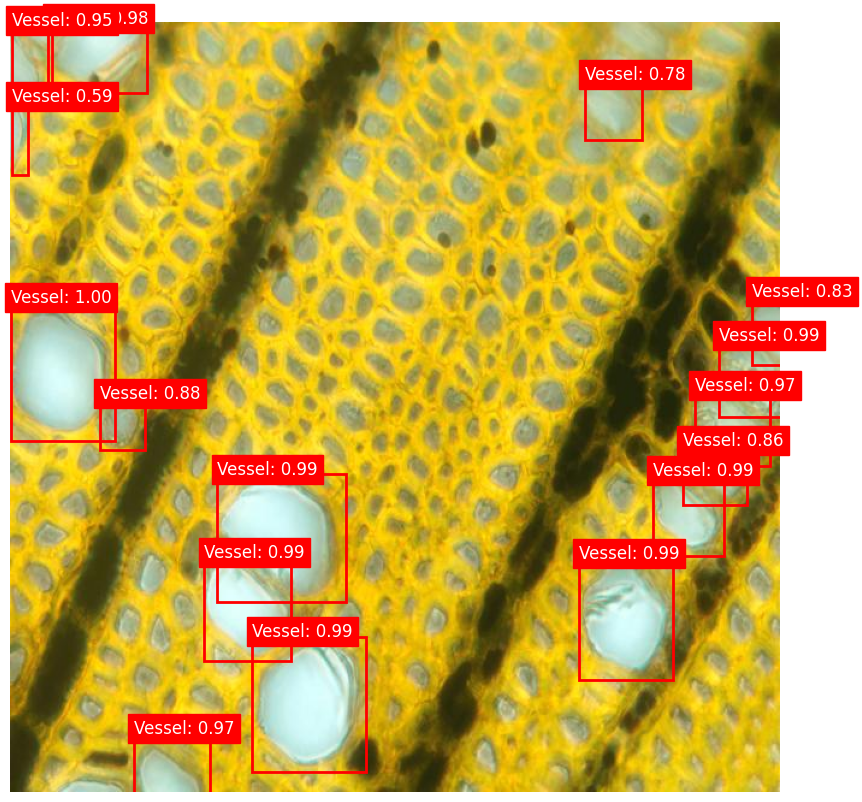

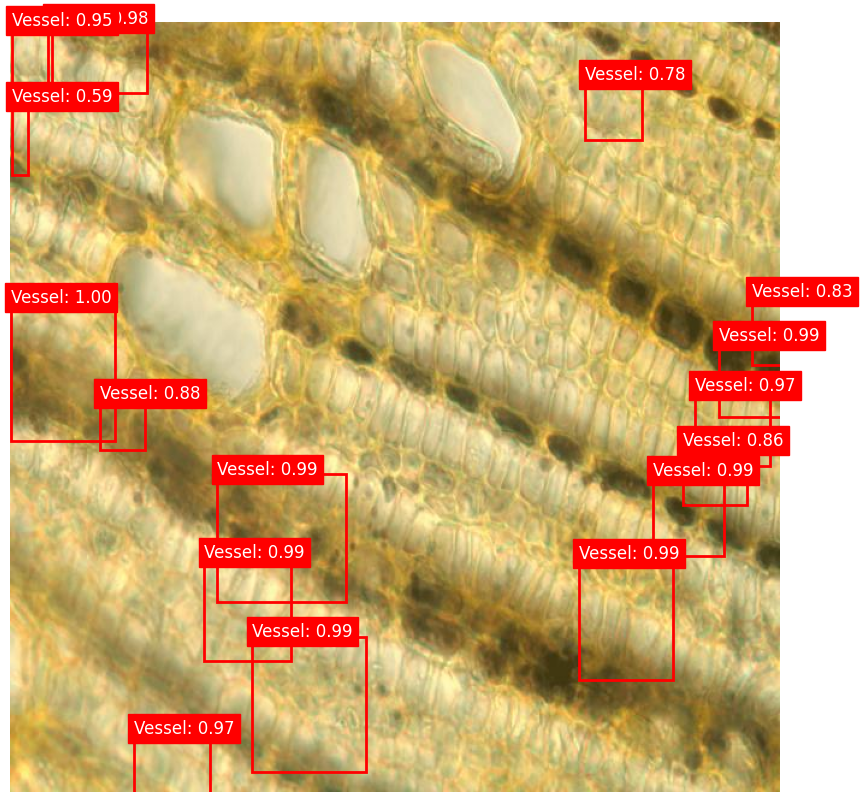

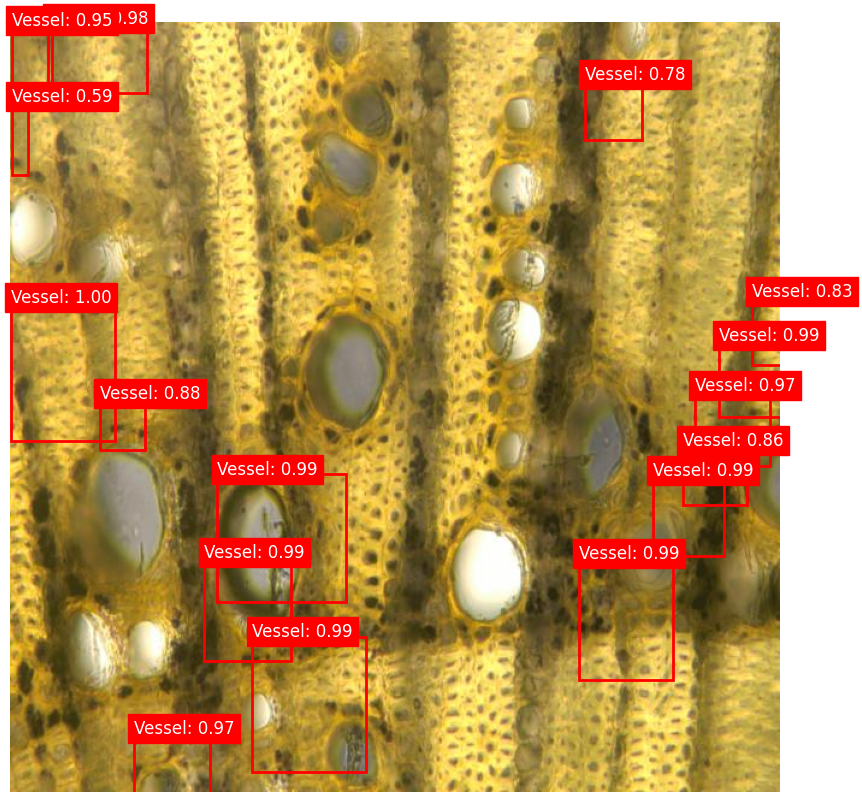

In [15]:
#3rd time's the charm! :,)
#I had to de-bug the visualization of the training set by changing some of the function names 
#the reason I had to do this was because I now save all the test set predictions on a .json file.

def train_predict(image_path, model, device):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([transforms.ToTensor()])
    image = transform(image).to(device)
    model.eval()
    with torch.no_grad():
        train_prediction = model([image])

    return train_prediction

image_path = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/train/Rca-3-stem-1_png.rf.73935039639678b37cfbebab9ab05b24.jpg'
image_path2 = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/test/Co-2-stem-1_png.rf.6797c19c7c90cf2adafc15f1edd291f7.jpg'
image_path3 = '/kaggle/input/automatic-plant-cell-detection/Vessel Detection.v1i.coco (1) 2/train/Ccr-3-root-10_png.rf.3be4ee8ab91ae017d6de558df35c30ff.jpg'
predictions = train_predict(image_path, model, device)

def display_prediction(image_path, predictions, threshold=0.57):
    image = Image.open(image_path).convert("RGB")
    plt.figure(figsize=(10,10))
    plt.imshow(image)

    t_prediction = predictions[0]
    boxes = t_prediction['boxes'].cpu().numpy()
    scores = t_prediction['scores'].cpu().numpy()
    labels = t_prediction['labels'].cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        if score > threshold:
            xmin, ymin, xmax, ymax = box
            plt.gca().add_patch(plt.Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                                              linewidth=2, edgecolor='red', facecolor='none'))
            plt.text(xmin, ymin, f"{dataset.categories[label-1]['name']}: {score:.2f}",
                     color='white', fontsize=12, backgroundcolor='red')

    plt.axis('off')
    plt.show()

# Display the predictions
display_prediction(image_path, predictions)
display_prediction(image_path2, predictions)
display_prediction(image_path3, predictions)

# Baseline is complete!

Now it FINALLY is time for experimenting! :) FINALLY my model works correctly WOOHOOOO!!!!! 2 weeks later... HAHAHHA

The problem ended up being how I saved the bounding boxes and categoryID's in the prediction function in tandem with the file order being incorrect. 

- I first put all of the files in order because that ended up being why I got flat out zero.


- I then had to convert the bounding box format back to [ x, y, width, height] since ChatGPT said COCO prefers that format for bounding boxes. so I changed the bounding box format within the predict function I built. The function originally defaulted it to [x1, x2, y1, y2] or something like that but it seems like the .json file was not a fan of that.


- I then instead of assigning the category ID's during the conversion to .csv, I included it in the actual prediction function to make sure the category ID's were 100% for sure related to the bounding boxes. I think the way I was doing it before had incorrect category ID assignents, which makes sense because it was mainly for output purposes. I also had to force the category ID value to be 1 within the prediction function because the way in which the model was built automatically assumes the categoryID as 2 instead of 1, which is fine, but it meant the number was wrong. So I just forced it to change as 1 by lebeling categoryID as 1 in the predict function. 

# Score Sheet

The place where I keep track of mAP score changes while experimenting!

Pre-debugging baseline: 0.00000

- after weeks of errors, I got ZERO.
- but you know what I'll take zero over errors and model failures. 

1st debugging attempt baseline: 0.00012

- This is when what I first changed was mainly the file order and learning how .json and .csv files work LOL
- because let's be so for real... I had no idea how those file formats worked HAHA

*Finally* Fully Debugged Baseline: 0.80904

- This is when I did the othe debugging mentioned above in the actual predict function!
- Now time to experiment! :)

Epoch + Optimizer Experiments: 0.81000

- Optimizer experiment was unsucessful, SGD ended up being the best anyways
- Epoch experiment was interesting though! 17 epochs ended up being the most effective on performance.

Batch Size Experiment: 0.81313

- lowering the batch size to 2 instead of 4 showed a small increase in performance!

Confidence Threshold Experiment: 0.90909

- WOW!!! This experiment was very successful. I added the confidence threshold to the predict value.
- More specifically, the confidence threshold that was the most successful so far was 0.6. But try 0.65 maybe or 0.55 tomorrow.

Batch Size of 1 Experiment?: 0.91238

- now THAT'S FUNNY I really messed around and found out HAHAHHA
- I guess maybe because the amount of data is so small, that it is actually beneficial to have a really small batch size and it won't overfit!

Confidence Threshold of 0.55 Experiment: 0.92668

- This tells me that the model might improve even more if I lower the confidence threshold
- and maybe I can revisit the number of epochs too, since it does really plateau a lot in the graph

Confidence Threshold of 0.5 Experiment: 0.89552

- Oh well...

CosineAnnealingLR Experiment: 0.90243

- After researching about this new learning rate scheduler it seemed so promising!
- oh well...


# To-Do List 

This is the place where I jot down my possible experiment ideas and keep track of my progress on them!

Current Experiment: 

- try a different learning rate scheduler method! (ChatGPT recommends CosineAnnealingLR)

Ideas On Deck: 


# The Graveyard

All the failed methods and experiments so I can keep track of what didn't work

- Different Optimizers (Adam, AdamW, RMSprop) (the original SGD was better than all of them lol)
- Epochs of 5, 10, 15, and 20 (5 and 10 underfitted, 15 was good but 17 was better, and 20 plateau'ed too much)
- Higher batch sizes such as 8 (lower batch sizes improved performance)
- Confidence Threshold of 0.7 (a little too high)
- Learning rate decrease (0.005 > 0.003)
- CosineAnnealingLR (was good but not as good as previous model)